In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from data.dataset import DiffusionDataset, get_dataloader, sin_1d
from utils.diffusion import Diffusion, cosine_schedule
from models.mlp import ScoreModel
from models.train import train_score_mlp

# Generate data

In [2]:
seed = 42
n_samples = 1000
dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=n_samples, seed=seed)

In [3]:
# raw dataset is in np.ndarray
print(dataset[0])
print(dataset.x[:5])
print(dataset.y[:5])

{'x': 0.37454012, 'y': 1.7878048}
[0.37454012 0.9507143  0.7319939  0.5986585  0.15601864]
[1.7878048  0.13477731 0.145768   0.63701797 1.8888878 ]


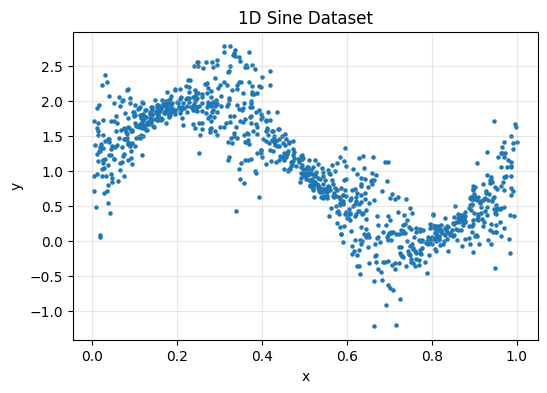

In [4]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
plt.scatter(dataset.x, dataset.y, s=5)

In [5]:
train_loader, test_loader, val_loader = get_dataloader(dataset, shuffle=True, batch_size=32)
print(f"Total number of samples in training set: {len(train_loader.dataset)}")
train_loader.dataset[0]

Total number of samples in training set: 800


{'x': 0.47417384, 'y': 1.1863415}

In [6]:
batch = next(iter(train_loader))
print(f"Number of samples in each batch: {batch['x'].shape[0]}")
print(f"Number of batches: {len(train_loader)}")
# batch is now in torch.Tensor, input to diffusion model
print(batch)
print(batch['y'].shape)

Number of samples in each batch: 32
Number of batches: 25
{'x': tensor([0.3252, 0.9295, 0.3342, 0.9507, 0.2401, 0.6064, 0.9209, 0.0265, 0.0369,
        0.1247, 0.2582, 0.5456, 0.4522, 0.8511, 0.5277, 0.8768, 0.9143, 0.4845,
        0.6847, 0.5027, 0.4926, 0.6637, 0.1112, 0.9699, 0.6294, 0.1663, 0.6279,
        0.1732, 0.7751, 0.0657, 0.3582, 0.1517]), 'y': tensor([ 1.6975,  1.2697,  2.6831,  0.1348,  1.9564,  0.3786,  0.5814,  1.1544,
         0.5388,  1.7752,  2.0593,  0.7386,  1.2514,  0.2396,  0.9823,  0.3501,
         0.5426,  1.1751, -0.3011,  1.0210,  1.2134, -1.2072,  1.4827,  0.7301,
         0.5263,  1.9599,  1.1840,  1.9507, -0.1793,  1.0113,  0.8326,  1.8122])}
torch.Size([32])


# Diffusion process

torch.Size([1001])
torch.Size([1001])
torch.Size([1001])
tensor(1.) tensor(0.0010)
tensor(0.) tensor(0.9990)
tensor(1.) tensor(1.9110e-15)


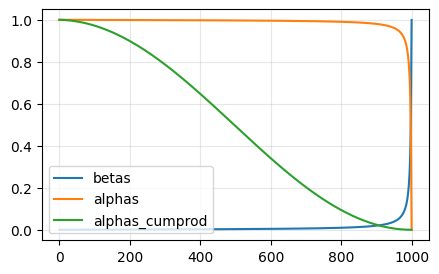

In [7]:
# check the schedules
betas, alphas, alphas_cumprod = cosine_schedule(1000)
print(betas.shape)
print(alphas.shape)
print(alphas_cumprod.shape)

print(alphas[0], alphas[-1])
print(betas[0], betas[-1])
print(alphas_cumprod[0], alphas_cumprod[-1])

plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.plot(betas, label='betas')
plt.plot(alphas, label='alphas')
plt.plot(alphas_cumprod, label='alphas_cumprod')
plt.legend(loc='lower left')

torch.Size([1000])
torch.Size([1000])
torch.Size([1000])


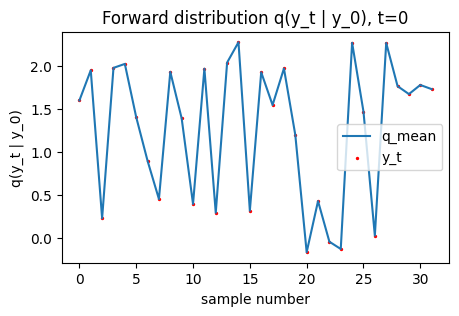

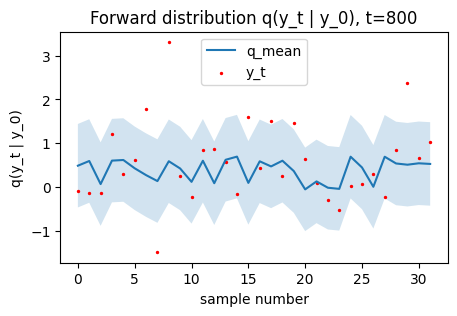

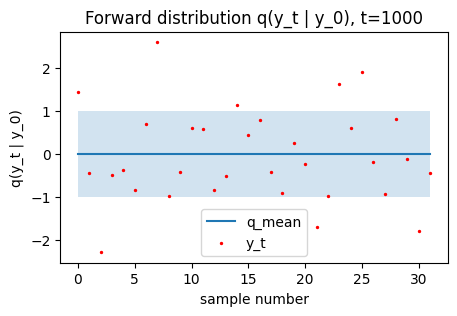

torch.Size([32])
torch.Size([32])


In [8]:
d = Diffusion(T=1000)
print(d.posterior_variance.shape)
print(d.posterior_mean_coef1.shape)
print(d.posterior_mean_coef2.shape)

y0 = batch['y']

plt.figure(figsize=(5, 3))
t = 0
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
t = 800
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
t = 1000
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

print(q_mean.shape)
print(q_var.shape)


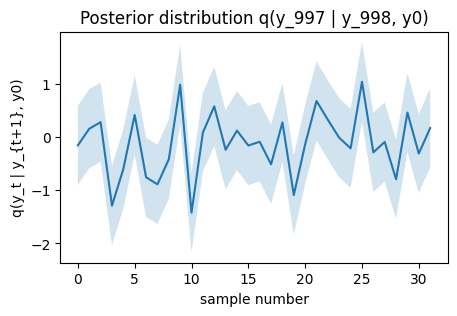

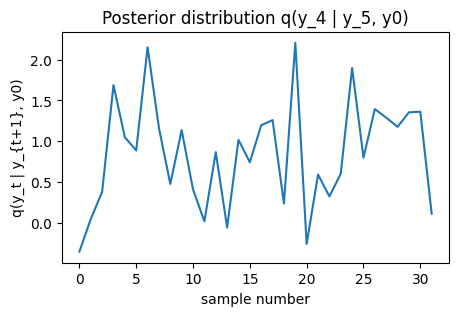

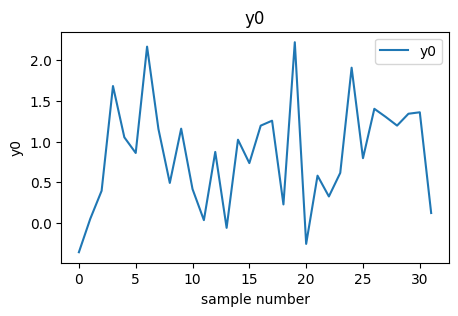

In [11]:
# sample y_T from q(y_T | y_0)
t = 998
q_mean, q_var = d.forward_q(y0, t) # get the forward distribution q(y_t | y_0)
y_t = q_mean + torch.randn_like(q_mean) * torch.sqrt(q_var) # sample y_T from q(y_t | y_0)
q_posterior_mean, q_posterior_var = d.reverse_q(y0, y_t, t-1)
plt.figure(figsize=(5, 3))
plt.title(f'Posterior distribution q(y_{t-1} | y_{t}, y0)')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_{t+1}, y0)')
plt.plot(q_posterior_mean, label='q_posterior_mean')
# fill between standard deviation
plt.fill_between(range(len(q_posterior_mean)), q_posterior_mean - q_posterior_var**0.5, q_posterior_mean + q_posterior_var**0.5, alpha=0.2)

t = 5
q_mean, q_var = d.forward_q(y0, t) # get the forward distribution q(y_t | y_0)
y_t = q_mean + torch.randn_like(q_mean) * torch.sqrt(q_var) # sample y_T from q(y_t | y_0)
q_posterior_mean, q_posterior_var = d.reverse_q(y0, y_t, t-1)
plt.figure(figsize=(5, 3))
plt.title(f'Posterior distribution q(y_{t-1} | y_{t}, y0)')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_{t+1}, y0)')
plt.plot(q_posterior_mean, label='q_posterior_mean')
# fill between standard deviation
plt.fill_between(range(len(q_posterior_mean)), q_posterior_mean - q_posterior_var**0.5, q_posterior_mean + q_posterior_var**0.5, alpha=0.2)

# plot the y0
plt.figure(figsize=(5, 3))
plt.title('y0')
plt.xlabel('sample number')
plt.ylabel('y0')
plt.plot(y0, label='y0')
plt.legend()
plt.show()


# Training

In [2]:
seed = 42
n_samples = 4000
dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=n_samples, seed=seed)
# Normalize y values to zero mean and unit variance
y_mean = dataset.y.mean()
y_std = dataset.y.std()
dataset.y = (dataset.y - y_mean) / y_std

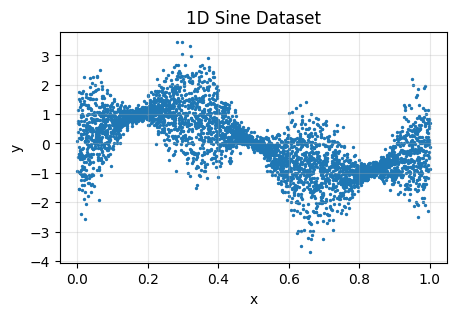

2800
0
1200


In [3]:
plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
plt.scatter(dataset.x, dataset.y, s=2)
plt.show()

train_loader, test_loader, val_loader = get_dataloader(dataset, shuffle=True, batch_size=32, train_ratio=0.7, val_ratio=0.3)
print(len(train_loader.dataset))
print(len(test_loader.dataset))
print(len(val_loader.dataset))

In [10]:
model, train_loss, val_loss = train_score_mlp(train_loader, val_loader, hidden_dims=[32, 64, 128], time_embed_dim=64, epoch_update=10, num_epochs=200, time_steps=1000, learning_rate=1e-4, device_type='cpu', save_path=None)

Epoch 0/200, Train Loss: 0.8092, Val Loss: 0.6266
Epoch 10/200, Train Loss: 0.4263, Val Loss: 0.3935
Epoch 20/200, Train Loss: 0.3925, Val Loss: 0.4131
Epoch 30/200, Train Loss: 0.4266, Val Loss: 0.3776
Epoch 40/200, Train Loss: 0.3818, Val Loss: 0.3523
Epoch 50/200, Train Loss: 0.3536, Val Loss: 0.3678
Epoch 60/200, Train Loss: 0.4275, Val Loss: 0.4084
Epoch 70/200, Train Loss: 0.3746, Val Loss: 0.3468
Epoch 80/200, Train Loss: 0.3920, Val Loss: 0.3649
Epoch 90/200, Train Loss: 0.3829, Val Loss: 0.3757
Epoch 100/200, Train Loss: 0.3877, Val Loss: 0.3784
Epoch 110/200, Train Loss: 0.3739, Val Loss: 0.3822
Epoch 120/200, Train Loss: 0.3742, Val Loss: 0.3723
Epoch 130/200, Train Loss: 0.3504, Val Loss: 0.3603
Epoch 140/200, Train Loss: 0.3570, Val Loss: 0.3530
Epoch 150/200, Train Loss: 0.3400, Val Loss: 0.3749
Epoch 160/200, Train Loss: 0.3553, Val Loss: 0.3873
Epoch 170/200, Train Loss: 0.3855, Val Loss: 0.3452
Epoch 180/200, Train Loss: 0.3846, Val Loss: 0.3816
Epoch 190/200, Train Lo

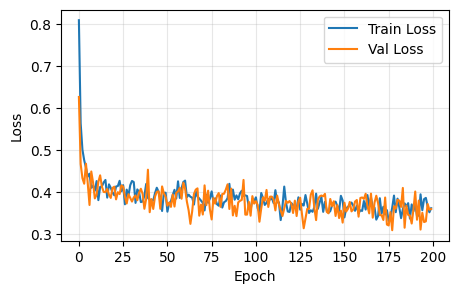

In [11]:
plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [12]:
def sample_from_model(model, location, num_samples, device):
    y_t = torch.randn(num_samples).to(device)
    x = torch.ones_like(y_t) * location
    diffusion = Diffusion(T=1000, device=device)
    
    for t in range(999, -1, -1):
        t_tensor = torch.ones_like(y_t) * (t+1)
        score = model(x, y_t, t_tensor)
        y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
        y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
        y_t = torch.clamp(y_t, min=-5.0, max=5.0) # y_t is still normalised
    return y_t

In [13]:
num_locations = 100
num_samples = 100
locations = torch.linspace(0, 1, num_locations)
results = np.zeros((num_locations,num_samples))
device = torch.device('cpu')

with tqdm(range(len(locations))) as pbar:
    for i, location in enumerate(locations):
        results[i] = sample_from_model(model, location, num_samples, device).detach().numpy()
        pbar.update(1)

results = results * y_std + y_mean

100%|██████████| 100/100 [01:03<00:00,  1.56it/s]


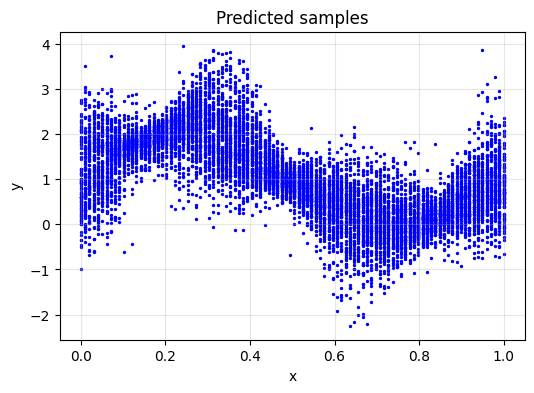

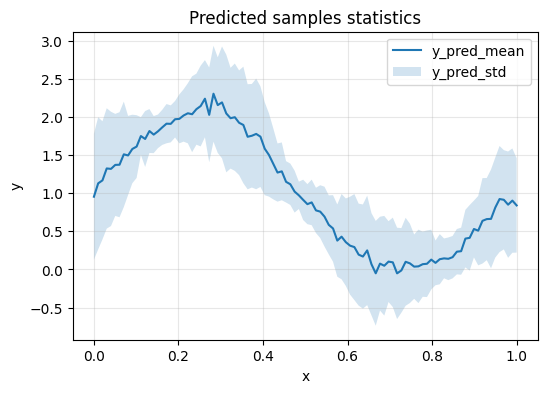

In [14]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples')
for i in range(results.shape[0]):
    plt.scatter(locations[i]*torch.ones(num_samples), results[i], s=2, c='b', label='y_t')
# plt.ylim(-5, 5)
# calculate the mean and std of the predicted samples
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples statistics')
y_pred_mean = np.mean(results, axis=1)
# get the variance of the predicted samples
y_pred_std = np.std(results, axis=1)
# plot the mean and std of the predicted samples
plt.plot(locations, y_pred_mean, label='y_pred_mean')
plt.fill_between(locations, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std')
plt.legend()

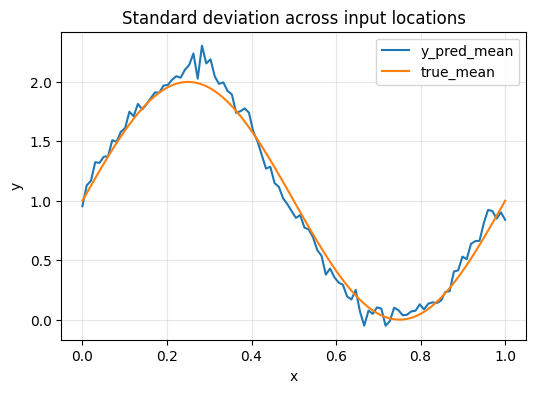

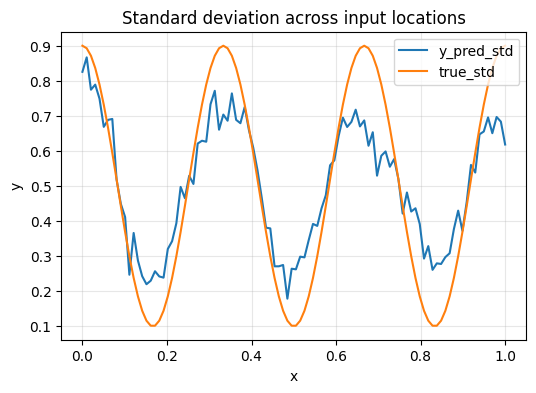

In [16]:
# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_mean, label='y_pred_mean')
# plot the true mean
plt.plot(locations, 1 + np.sin(2 * np.pi * locations), label='true_mean')
plt.legend()

# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_std, label='y_pred_std')
# plot the true standard deviation
plt.plot(locations, 0.5 + 0.4 * np.cos(6 * np.pi * locations), label='true_std')
# plt.ylim(-1, 1.5)
plt.legend()

# Graveyard

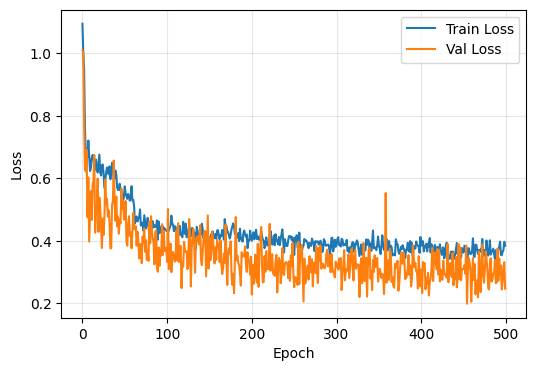

In [5]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [7]:
num_locations = 200
x_locations = torch.linspace(0, 1, num_locations)
num_samples = 20
d = Diffusion(T=1000)
results = torch.zeros(num_locations,num_samples)

model.eval()
with torch.no_grad():
    with tqdm(range(len(x_locations))) as pbar:
        for i, location in enumerate(x_locations):
            x = torch.ones(num_samples) * location
            yt = torch.randn_like(x)
            for t in range(999,-1,-1):
                t_tensor = torch.ones(num_samples) * t
                score = model(x, yt, t_tensor)

                yt = (1/torch.sqrt(d.alphas[t])) * (yt - ((1-d.alphas[t+1])/torch.sqrt(1-d.alphas_cumprod[t+1])) * score)
                yt += torch.randn_like(yt) * torch.sqrt(d.betas[t+1])
            results[i] = yt
            pbar.update(1)

100%|██████████| 200/200 [00:20<00:00,  9.75it/s]


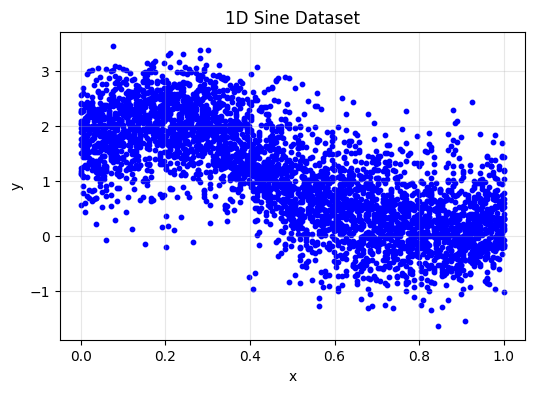

In [8]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
for i in range(results.shape[1]):
    plt.scatter(x_locations, results[:, i], s=10, c='b')
plt.show()


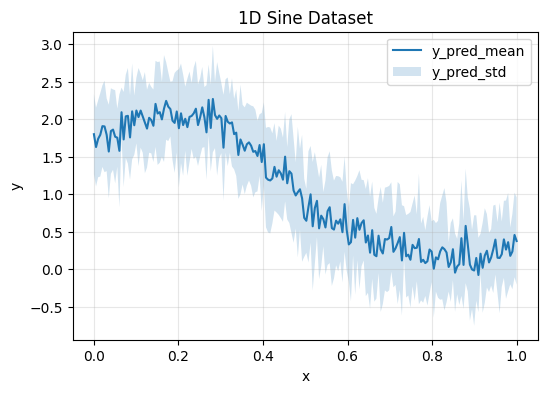

In [9]:
# calculate the mean of the y_pred
y_pred_mean = torch.mean(results, dim=1)
# calculate the std of the y_pred
y_pred_std = torch.std(results, dim=1)
# plot the y_pred
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
plt.plot(x_locations, y_pred_mean, label='y_pred_mean')
plt.fill_between(x_locations, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std')
plt.legend()
plt.show()